# Fuzzy Logic Model for the BMWP/Col Water Quality Index

This notebook builds a Mamdani fuzzy inference system that predicts the **BMWP/Col** biological water quality index of the Cali River from five physicochemical predictors (BOD5, DO, turbidity, conductivity and TDS).

Membership functions for the predictors are defined from the literature/expert criteria, and the rule base is generated automatically: each observation in the dataset becomes one fuzzy rule. The model is then evaluated **in sample** (see the Limitations section).

## ⚠️ Important note on methodology

The original implementation below uses automatic rule generation from the
complete dataset, which creates in-sample dependency between rule construction
and model evaluation. Performance metrics in this notebook reflect **in-sample
fit only** and should not be interpreted as evidence of out-of-sample
generalisation capacity.

A redesigned implementation eliminating this dependency is available in:
- `01e_fuzzy_redesign_comparison.ipynb` (all approaches compared)
- `01f_fuzzy_final.ipynb` (final publication-ready implementation)

The redesigned system uses Fuzzy C-Means clustering for membership function
estimation and reduced antecedent sets, evaluated under full LOOCV.
See Section 8 of 01e for the methodological justification.

*Modified 2026-06-23 — methodological warning added; supports article Methods/Results.*

## Data Loading

In [1]:
import pandas as pd

# Cali River physicochemical + BMWP dataset (source: CVC)
file_path = "../../data/Database - BMWP.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()
df

,Estación,COT,DBO5,DBOu,DBO5s,DQO,Dureza,Fósforo,Fosfatos,Hierro,...,Turbiedad,pH,Conductividad,OD,Temperatura,Coliformes,Profundidad,Velocidad,Caudal,BMWP
0,RF2,1.69,2,4,2,10.00,35.5,0.114,0.015,0.236,...,2.71,7.14,80,6.30,15.00,1012,0.44,0.55,1.39,52
1,RC2,11.00,2,5,2,10.00,49.4,0.149,0.191,0.831,...,57.60,6.89,115,7.69,20.30,6867,0.36,0.32,1.59,45
2,RA3,7.92,3,4,2,13.71,113.0,0.050,0.150,0.600,...,10.60,7.92,371,6.82,22.87,9804,0.33,0.71,0.92,28
3,RA2,3.04,2,3,2,10.00,98.4,0.050,0.150,0.411,...,10.40,7.90,294,7.01,19.94,2613,0.38,0.82,0.83,72
4,RA3,4.33,35,26,15,70.60,108.0,1.500,1.080,0.195,...,10.70,6.94,300,5.05,25.23,19863,0.34,0.66,0.97,56
5,RF3,7.20,2,3,2,10.00,47.5,0.443,0.221,0.100,...,2.00,8.16,112,5.90,18.62,676,0.46,0.42,0.87,37
6,RA1,17.90,2,2,2,10.00,68.5,0.050,0.150,0.200,...,4.44,7.99,207,6.53,16.75,1135,0.20,0.47,0.09,116
7,RC2,26.20,2,4,2,10.00,59.1,0.271,0.236,0.100,...,2.00,8.18,140,6.20,23.40,197,0.50,0.18,0.97,75
8,RA4,7.38,14,35,12,88.50,216.0,0.256,0.221,17.500,...,88.10,7.15,500,3.20,29.30,24196,0.49,0.76,1.50,35
9,RA4,5.97,17,21,12,49.50,206.0,0.845,0.412,25.300,...,67.50,7.09,766,5.91,23.77,19863,0.39,0.44,0.69,9


In [2]:
# Keep only the predictors and the BMWP response used by the model
columns_needed = ['OD', 'DBO5', 'SDT', 'Turbiedad', 'Conductividad', 'BMWP']
filtered_df = df[columns_needed]

print("First rows of the filtered dataset:")
display(filtered_df.head())
print("\nDescriptive statistics:")
display(filtered_df.describe())

First rows of the filtered dataset:


,OD,DBO5,SDT,Turbiedad,Conductividad,BMWP
0,6.30,2,50,2.71,80,52
1,7.69,2,100,57.60,115,45
2,6.82,3,124,10.60,371,28
3,7.01,2,50,10.40,294,72
4,5.05,35,196,10.70,300,56



Descriptive statistics:


,OD,DBO5,SDT,Turbiedad,Conductividad,BMWP
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,5.925000,6.000000,125.666667,17.779444,263.500000,60.055556
std,1.093619,8.512966,87.982619,25.965117,175.512108,32.074311
min,3.200000,2.000000,50.000000,2.000000,80.000000,9.000000
25%,5.377500,2.000000,89.500000,2.177500,141.000000,35.500000
50%,6.060000,2.000000,105.500000,6.690000,207.000000,60.500000
75%,6.672500,6.000000,117.250000,11.150000,300.000000,88.750000
max,7.690000,35.000000,410.000000,88.100000,766.000000,116.000000


### Outlier removal

Excessively high values are trimmed with an IQR rule. The upper bound uses a more tolerant margin (2.5 x IQR) to preserve variability given the small sample size.

In [3]:
# IQR-based removal of excessively high values (tolerant upper bound)
def remove_excessive_outliers(df, column, margin=2.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR          # standard lower bound
    upper_bound = Q3 + margin * IQR       # tolerant upper bound
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

filtered_df_cleaned = filtered_df.copy()
for column in ['DBO5', 'Turbiedad', 'Conductividad', 'OD', 'SDT']:
    filtered_df_cleaned = remove_excessive_outliers(filtered_df_cleaned, column, margin=2.5)

print(f"Original dataset size: {len(filtered_df)}")
print(f"Size after outlier removal: {len(filtered_df_cleaned)}")
print("\nDescriptive statistics of the clean dataset:")
print(filtered_df_cleaned.describe())

Original dataset size: 18
Size after outlier removal: 14

Descriptive statistics of the clean dataset:
              OD       DBO5         SDT  Turbiedad  Conductividad        BMWP
count  14.000000  14.000000   14.000000  14.000000      14.000000   14.000000
mean    6.057143   2.857143   91.928571   6.866429     218.714286   66.857143
std     0.821859   1.994498   25.817300   7.549631     112.240421   32.062096
min     4.330000   2.000000   50.000000   2.000000      80.000000   13.000000
25%     5.592500   2.000000   73.500000   2.000000     141.000000   40.750000
50%     6.250000   2.000000  103.500000   3.820000     196.500000   73.500000
75%     6.672500   2.000000  107.000000   9.472500     293.500000   92.250000
max     7.010000   8.000000  124.000000  30.100000     469.000000  116.000000


## Model Definition

The BMWP membership functions are based on the standard BMWP/Col quality classes found in the literature.

In [4]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Input variables (antecedents): universes and triangular membership functions
dbo5 = ctrl.Antecedent(np.arange(0, 9.1, 0.1), 'DBO5')
od = ctrl.Antecedent(np.arange(5, 7.6, 0.1), 'OD')
turbiedad = ctrl.Antecedent(np.arange(0, 31.1, 0.1), 'Turbiedad')
conductividad = ctrl.Antecedent(np.arange(50, 501, 1), 'Conductividad')
sdt = ctrl.Antecedent(np.arange(30, 131, 1), 'SDT')

# Biochemical Oxygen Demand (BOD5)
dbo5['Bajo'] = fuzz.trimf(dbo5.universe, [0, 2, 3])
dbo5['Medio'] = fuzz.trimf(dbo5.universe, [2.5, 4, 6])
dbo5['Alto'] = fuzz.trimf(dbo5.universe, [5, 7, 9])

# Dissolved Oxygen (DO)
od['Bajo'] = fuzz.trimf(od.universe, [4, 5, 5.8])
od['Medio'] = fuzz.trimf(od.universe, [5.5, 6.3, 6.9])
od['Alto'] = fuzz.trimf(od.universe, [6.5, 7, 7.5])

# Turbidity
turbiedad['Baja'] = fuzz.trimf(turbiedad.universe, [0, 2, 5])
turbiedad['Media'] = fuzz.trimf(turbiedad.universe, [4, 8, 12])
turbiedad['Alta'] = fuzz.trimf(turbiedad.universe, [10, 20, 31])

# Conductivity
conductividad['Baja'] = fuzz.trimf(conductividad.universe, [50, 80, 150])
conductividad['Media'] = fuzz.trimf(conductividad.universe, [100, 250, 400])
conductividad['Alta'] = fuzz.trimf(conductividad.universe, [300, 450, 500])

# Total Dissolved Solids (TDS)
sdt['Bajo'] = fuzz.trimf(sdt.universe, [30, 50, 70])
sdt['Medio'] = fuzz.trimf(sdt.universe, [60, 90, 110])
sdt['Alto'] = fuzz.trimf(sdt.universe, [100, 120, 130])

# Output variable (consequent): BMWP index, classes follow the BMWP/Col literature
bmwp = ctrl.Consequent(np.arange(0, 121, 1), 'bmwp')
bmwp['Muy crítica'] = fuzz.trimf(bmwp.universe, [0, 0, 15])
bmwp['Crítica'] = fuzz.trimf(bmwp.universe, [15, 35, 35])
bmwp['Dudosa'] = fuzz.trimf(bmwp.universe, [36, 60, 60])
bmwp['Aceptable'] = fuzz.trimf(bmwp.universe, [61, 100, 100])
bmwp['Buena'] = fuzz.trimf(bmwp.universe, [101, 120, 120])

## Visualisation of the BMWP membership functions

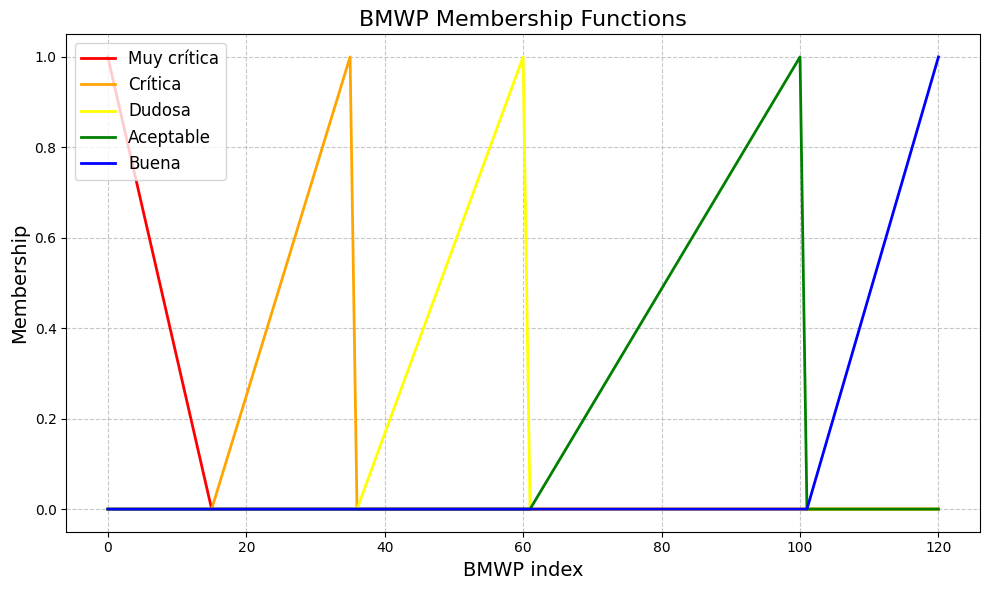

In [5]:
import matplotlib.pyplot as plt

colors = {
    "Muy crítica": "red",
    "Crítica": "orange",
    "Dudosa": "yellow",
    "Aceptable": "green",
    "Buena": "blue",
}

plt.figure(figsize=(10, 6))
for label, color in colors.items():
    plt.plot(bmwp.universe, bmwp[label].mf, color=color, label=label, linewidth=2)

plt.title("BMWP Membership Functions", fontsize=16)
plt.xlabel("BMWP index", fontsize=14)
plt.ylabel("Membership", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Predictor Categorisation

Each crisp value is mapped to its dominant linguistic category, so that every observation can be turned into a fuzzy rule.

In [6]:
import skfuzzy as fuzz

# Generic helper: assign a crisp value to the linguistic category with the
# highest membership degree under the previously defined membership functions.
def categorize_variable(value, universe, mf_dict):
    memberships = {cat: fuzz.interp_membership(universe, mf, value)
                   for cat, mf in mf_dict.items()}
    return max(memberships, key=memberships.get)

def categorize_dbo5(value):
    return categorize_variable(value, dbo5.universe,
        {'Bajo': dbo5['Bajo'].mf, 'Medio': dbo5['Medio'].mf, 'Alto': dbo5['Alto'].mf})

def categorize_od(value):
    return categorize_variable(value, od.universe,
        {'Bajo': od['Bajo'].mf, 'Medio': od['Medio'].mf, 'Alto': od['Alto'].mf})

def categorize_turbiedad(value):
    return categorize_variable(value, turbiedad.universe,
        {'Baja': turbiedad['Baja'].mf, 'Media': turbiedad['Media'].mf, 'Alta': turbiedad['Alta'].mf})

def categorize_conductividad(value):
    return categorize_variable(value, conductividad.universe,
        {'Baja': conductividad['Baja'].mf, 'Media': conductividad['Media'].mf, 'Alta': conductividad['Alta'].mf})

def categorize_sdt(value):
    return categorize_variable(value, sdt.universe,
        {'Bajo': sdt['Bajo'].mf, 'Medio': sdt['Medio'].mf, 'Alto': sdt['Alto'].mf})

# Categorise the response variable too
def categorize_bmwp(value):
    return categorize_variable(value, bmwp.universe, {
        'Muy crítica': bmwp['Muy crítica'].mf,
        'Crítica': bmwp['Crítica'].mf,
        'Dudosa': bmwp['Dudosa'].mf,
        'Aceptable': bmwp['Aceptable'].mf,
        'Buena': bmwp['Buena'].mf,
    })

def categorize_row(row):
    return {
        'DBO5': categorize_dbo5(row['DBO5']),
        'OD': categorize_od(row['OD']),
        'Turbiedad': categorize_turbiedad(row['Turbiedad']),
        'Conductividad': categorize_conductividad(row['Conductividad']),
        'SDT': categorize_sdt(row['SDT']),
        'BMWP': categorize_bmwp(row['BMWP']),
    }

categorized_df = filtered_df_cleaned.apply(categorize_row, axis=1, result_type='expand')
print(categorized_df)

     DBO5     OD Turbiedad Conductividad    SDT         BMWP
0    Bajo  Medio      Baja          Baja   Bajo       Dudosa
2   Medio   Alto     Media          Alta   Alto      Crítica
3    Bajo   Alto     Media         Media   Bajo    Aceptable
5    Bajo  Medio      Baja          Baja  Medio       Dudosa
6    Bajo  Medio      Baja         Media   Alto        Buena
7    Bajo  Medio      Baja         Media   Alto    Aceptable
10   Bajo  Medio      Baja         Media   Bajo    Aceptable
11   Alto  Medio     Media          Baja  Medio    Aceptable
12   Bajo   Alto      Baja         Media   Alto    Aceptable
13   Alto   Bajo     Media          Alta   Alto  Muy crítica
14   Bajo   Bajo     Media         Media  Medio    Aceptable
15   Bajo   Bajo      Baja         Media  Medio    Aceptable
16   Bajo   Bajo      Alta         Media   Alto      Crítica
17   Bajo   Alto      Baja         Media  Medio    Aceptable


## Rule Generation

One fuzzy rule is created per observation: the antecedent is the conjunction of the categorised predictors and the consequent is the categorised BMWP class.

In [7]:
rules = []
for _, row in categorized_df.iterrows():
    antecedent = (
        dbo5[row['DBO5']] &
        od[row['OD']] &
        turbiedad[row['Turbiedad']] &
        conductividad[row['Conductividad']] &
        sdt[row['SDT']]
    )
    consequent = bmwp[row['BMWP']]
    rules.append(ctrl.Rule(antecedent, consequent))

bmwp_ctrl = ctrl.ControlSystem(rules)
bmwp_sim = ctrl.ControlSystemSimulation(bmwp_ctrl)
print(f"{len(rules)} rules were generated for the fuzzy system.")

14 rules were generated for the fuzzy system.


## Evaluation

The model is run on every observation used to build the rules (in-sample). The defuzzified output is re-categorised into a BMWP class and compared with the real class.

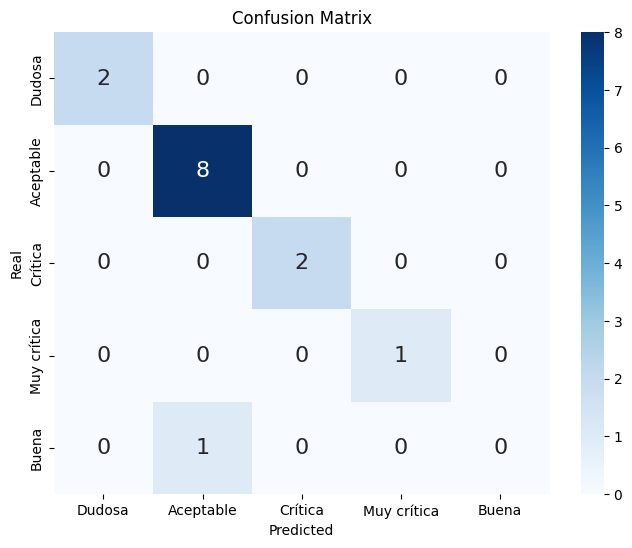


Classification report:
              precision    recall  f1-score   support

      Dudosa       1.00      1.00      1.00         2
   Aceptable       0.89      1.00      0.94         8
     Crítica       1.00      1.00      1.00         2
 Muy crítica       1.00      1.00      1.00         1
       Buena       0.00      0.00      0.00         1

    accuracy                           0.93        14
   macro avg       0.78      0.80      0.79        14
weighted avg       0.87      0.93      0.89        14



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

predictions = []
real_categories = categorized_df['BMWP']

for _, row in categorized_df.iterrows():
    try:
        bmwp_sim.input['DBO5'] = row['DBO5']
        bmwp_sim.input['OD'] = row['OD']
        bmwp_sim.input['Turbiedad'] = row['Turbiedad']
        bmwp_sim.input['Conductividad'] = row['Conductividad']
        bmwp_sim.input['SDT'] = row['SDT']
        bmwp_sim.compute()
        predictions.append(categorize_bmwp(bmwp_sim.output['bmwp']))
    except Exception as e:
        print(f"Error processing row: {row.to_dict()}, error: {e}")
        predictions.append("Unknown")

labels_present = list(set(real_categories) | set(predictions))
cm = confusion_matrix(real_categories, predictions, labels=labels_present)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=labels_present, yticklabels=labels_present)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

print("\nClassification report:")
print(classification_report(real_categories, predictions, labels=labels_present))

### Performance indicators

In [9]:
from sklearn.metrics import cohen_kappa_score, roc_auc_score, accuracy_score

real_categories = real_categories.astype(str)
predictions = [str(p) for p in predictions]

# Correctly Classified Instances (overall accuracy)
cci = accuracy_score(real_categories, predictions)
print(f"Correctly Classified Instances (CCI): {cci:.4f}")

try:
    kappa = cohen_kappa_score(real_categories, predictions)
    print(f"Cohen's Kappa: {kappa:.4f}")
except ValueError as e:
    print(f"Could not compute Kappa: {e}")

cm = confusion_matrix(real_categories, predictions, labels=labels_present)
total = np.sum(cm)

# Weighted global sensitivity and simple-average global specificity
sensitivity_global = 0.0
specificity_sum = 0.0
classes_with_data = 0
per_class = {}
for i, label in enumerate(labels_present):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = total - (tp + fn + fp)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity_global += sens * (tp + fn)
    if (tn + fp) > 0:
        specificity_sum += spec
        classes_with_data += 1
    per_class[label] = (sens, spec)

sensitivity_global /= total
specificity_global = specificity_sum / classes_with_data
print(f"\nGlobal sensitivity: {sensitivity_global:.4f}")
print(f"Global specificity: {specificity_global:.4f}")

print("\nPer-class sensitivity / specificity:")
for label, (sens, spec) in per_class.items():
    print(f"Class '{label}': sensitivity = {sens:.4f}, specificity = {spec:.4f}")

# Micro-averaged AUC over one-hot encoded labels
real_bin = pd.get_dummies(real_categories).reindex(columns=labels_present, fill_value=0)
pred_bin = pd.get_dummies(predictions).reindex(columns=labels_present, fill_value=0)
try:
    auc_micro = roc_auc_score(real_bin, pred_bin, average="micro", multi_class="ovo")
    print(f"\nArea Under the Curve (AUC, micro-average): {auc_micro:.4f}")
except ValueError as e:
    print(f"Could not compute AUC: {e}")

Correctly Classified Instances (CCI): 0.9286
Cohen's Kappa: 0.8783

Global sensitivity: 0.9286
Global specificity: 0.9667

Per-class sensitivity / specificity:
Class 'Dudosa': sensitivity = 1.0000, specificity = 1.0000
Class 'Aceptable': sensitivity = 1.0000, specificity = 0.8333
Class 'Crítica': sensitivity = 1.0000, specificity = 1.0000
Class 'Muy crítica': sensitivity = 1.0000, specificity = 1.0000
Class 'Buena': sensitivity = 0.0000, specificity = 1.0000

Area Under the Curve (AUC, micro-average): 0.9554


## Visualisation: ROC curve

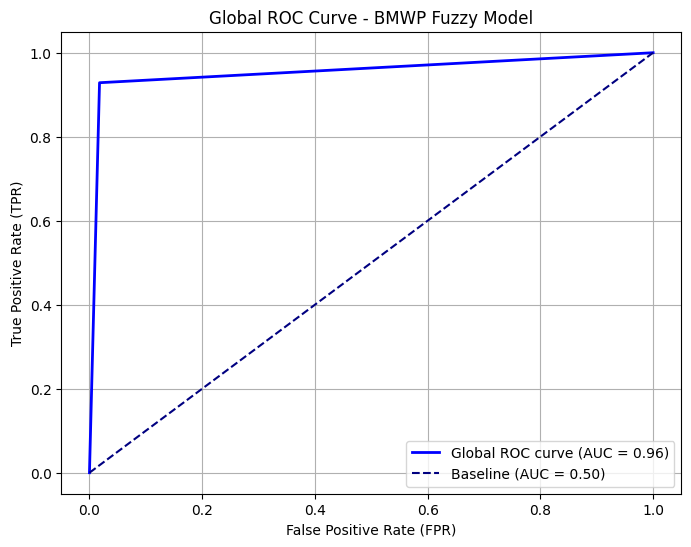

In [10]:
from sklearn.metrics import roc_curve, auc

fpr_micro, tpr_micro, _ = roc_curve(real_bin.values.ravel(), pred_bin.values.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(8, 6))
plt.plot(fpr_micro, tpr_micro, color='blue', lw=2,
         label=f'Global ROC curve (AUC = {roc_auc_micro:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Baseline (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Global ROC Curve - BMWP Fuzzy Model')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## Limitations

Rules were derived from the same observations used for evaluation. Performance metrics therefore reflect in-sample fit and should not be interpreted as evidence of out-of-sample generalisation capacity.

A proper out-of-sample assessment (e.g. leave-one-out cross-validation) is a future improvement, not something implemented here.